# 02 — EDA: Sales Analysis

## Purpose
EDA stands for **Exploratory Data Analysis** — it means studying the data to understand
patterns, distributions, and relationships before building any model.

This notebook answers the **core business questions**:
- Which branches sell the most?
- How do dine-in (Restaurant) vs takeout (Para Llevar) compare?
- What are the best-selling products overall?
- What are the top products at each branch by units sold?
- What are the top products at each branch by revenue?

## Input
`data/intermediate/datanomodifier.csv` — produced by `00_data_pipeline.ipynb`

## Run order
Run after `00_data_pipeline.ipynb`. Does not depend on `01_data_cleaning.ipynb`.

## Cell 1 — Path configuration

Set `USE_GITHUB = False` when running locally after cloning the repo.
Set `USE_GITHUB = True` when running in Google Colab (reads files directly from GitHub).

> **Note:** Notebooks 00–06 depend on `datanomodifier.csv` which lives in
> `data/intermediate/`. This file is not in the GitHub repo (too large).
> You must generate it locally by running `00_data_pipeline.ipynb` first.

In [1]:
import os

# ─── CHANGE THIS FLAG ─────────────────────────────────────────────────
USE_GITHUB  = False   # True = read from GitHub (Colab), False = read from local clone
# ───────────────────────────────────────────────────────────────────────

GITHUB_BASE = "https://media.githubusercontent.com/media/DiegoLarrieta/PanemReto/main"

if USE_GITHUB:
    PROCESSED_DIR    = f"{GITHUB_BASE}/data/processed"
    WEATHER_DIR      = f"{GITHUB_BASE}/data/weather"
    RAW_DIR          = f"{GITHUB_BASE}/data/raw/Complete Data"
    INTERMEDIATE_DIR = None  # not in repo — run 00_data_pipeline.ipynb locally first
else:
    PROJECT_ROOT     = os.path.abspath(os.path.join(os.getcwd(), ".."))
    PROCESSED_DIR    = os.path.join(PROJECT_ROOT, "data", "processed")
    WEATHER_DIR      = os.path.join(PROJECT_ROOT, "data", "weather")
    RAW_DIR          = os.path.join(PROJECT_ROOT, "data", "raw", "Complete Data")
    INTERMEDIATE_DIR = os.path.join(PROJECT_ROOT, "data", "intermediate")

print("INTERMEDIATE_DIR:", INTERMEDIATE_DIR)

INTERMEDIATE_DIR: /Users/diego/Documents/ChallengeAI/data/intermediate


## Cell 2 — Load and clean data

We load `datanomodifier.csv` and apply the same cleaning steps every time so this
notebook can run independently without relying on any other notebook's state.

At the end of this cell we create two dataframes:
- **`df`** — the full loaded dataset after cleaning
- **`base`** — a filtered subset used in every analysis below:
  - `is_modifier == False` → only base products, not customization rows
  - `action == 'Venta'` → only completed sales, not cancellations or voids
  - `item` is not null → no blank product names

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

# ── Load ──────────────────────────────────────────────────────────────
input_path = os.path.join(INTERMEDIATE_DIR, "datanomodifier.csv")
df = pd.read_csv(input_path, low_memory=False)
print(f"Loaded: {len(df):,} rows | {df.shape[1]} columns")

# ── Parse datetime columns ────────────────────────────────────────────
# They are stored as strings in CSV and need to be converted back to datetime
for col in ["operating_date", "closing_time", "captured_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# ── Fix is_modifier to boolean ────────────────────────────────────────
# Raw POS exports mix 'True'/'False' strings with actual booleans
df["is_modifier"] = (
    df["is_modifier"].astype("string").str.strip().str.lower()
    .map({"true": True, "false": False}).fillna(False).astype(bool)
)

# ── Ensure numeric types ─────────────────────────────────────────────
df["quantity"]     = pd.to_numeric(df["quantity"],     errors="coerce").fillna(0)
df["total_ticket"] = pd.to_numeric(df["total_ticket"], errors="coerce").fillna(0)
df["tavg"]         = pd.to_numeric(df["tavg"],         errors="coerce")

# ── Remove beverages ─────────────────────────────────────────────────
# Not the forecasting target — different supply chain logic
df = df[~df["group"].isin(["CAFE Y BEBIDAS CALIENTES", "JUGOS Y BEBIDAS FRIAS"])].copy()

# ── Standardize branch names ─────────────────────────────────────────
# Some branches appear under two names due to a POS system reconfiguration
df["sucursal"] = df["sucursal"].replace({
    "Panem - Hotel Kavia N"      : "Panem - Hotel Kavia",
    "Panem - Plaza QIN N"        : "Panem - Plaza QIN",
    "Panem - Hospital Zambrano N": "Panem - Hospital Zambrano",
    "Panem - La Carreta N"       : "Panem - Carreta",
})

# ── Fix product name typos ────────────────────────────────────────────
df["item"] = df["item"].replace({"SANDWITCH ENSALADA POLLO": "SANDWICH ENSALADA POLLO"})

# ── Temperature label ─────────────────────────────────────────────────
df["cold_or_warm"] = np.where(df["tavg"] >= 25, "warm", "cold")

# ── Create `base` ─────────────────────────────────────────────────────
# base = only real sold items (no modifier rows, only completed sales)
base = df[
    (df["is_modifier"] == False) &
    (df["action"]      == "Venta") &
    (df["item"].notna())
].copy()

print(f"df shape:   {df.shape}")
print(f"base shape: {base.shape}")
print(f"Branches:   {sorted(base['sucursal'].dropna().unique())}")

Loaded: 2,579,572 rows | 50 columns
df shape:   (1439071, 50)
base shape: (1412688, 50)
Branches:   ['Panem - Carreta', 'Panem - Credi Club', 'Panem - Hospital Zambrano', 'Panem - Hotel Kavia', 'Panem - Plaza Nativa', 'Panem - Plaza QIN', 'Panem - Punto Valle']


## Analysis 1 — Total sales by branch (quantity)

Which branch sells the most units overall?

The `pct` column shows each branch's share of total volume. This helps us understand
the relative size of each location and contextualize comparisons between them.

,sucursal,qty_sold,pct
1,Panem - Punto Valle,420378.0,26.0
2,Panem - Plaza QIN,326523.0,20.2
3,Panem - Hotel Kavia,309505.2,19.1
4,Panem - Hospital Zambrano,275763.0,17.0
5,Panem - Carreta,162855.0,10.1
6,Panem - Plaza Nativa,103489.0,6.4
7,Panem - Credi Club,20670.0,1.3


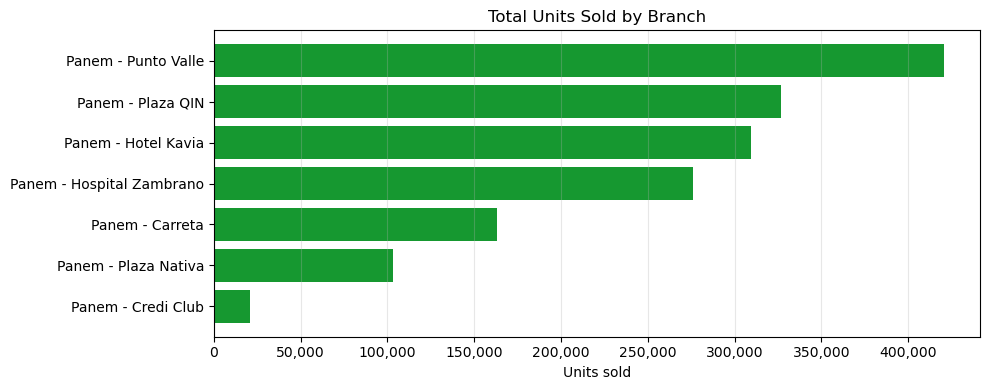

In [3]:
qty_by_branch = (
    base.groupby("sucursal", as_index=False)["quantity"]
        .sum()
        .rename(columns={"quantity": "qty_sold"})
        .sort_values("qty_sold", ascending=False)
        .reset_index(drop=True)
)
qty_by_branch.index = qty_by_branch.index + 1
qty_by_branch["pct"] = (qty_by_branch["qty_sold"] / qty_by_branch["qty_sold"].sum() * 100).round(1)

display(qty_by_branch)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(qty_by_branch["sucursal"][::-1], qty_by_branch["qty_sold"][::-1], color="#169830")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Units sold")
ax.set_title("Total Units Sold by Branch")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis 2 — Sales by channel: Restaurant vs Para Llevar

**Para llevar** = takeout | **Restaurant** = dine-in

The channel mix tells us how customers prefer to consume each branch's products.
Takeout-heavy branches may have different stock needs than dine-in-heavy ones,
since takeout tends to be more predictable in volume and timing.

In [4]:
# Units sold per branch x channel
channel_qty = (
    base.pivot_table(
        index="sucursal",
        columns="order_type",
        values="quantity",
        aggfunc="sum",
        fill_value=0
    )
)
channel_qty["TOTAL"] = channel_qty.sum(axis=1)
channel_qty = channel_qty.sort_values("TOTAL", ascending=False)

print("=== Units sold by channel ===")
display(channel_qty)

# Percentage mix per branch
channel_pct = (
    channel_qty.drop(columns="TOTAL")
    .div(channel_qty["TOTAL"], axis=0)
    .mul(100).round(1)
)
print("\n=== Channel mix % per branch ===")
display(channel_pct)

=== Units sold by channel ===


order_type,Para llevar,Restaurant,TOTAL
sucursal,,,
Panem - Punto Valle,221182.0,199196.0,420378.0
Panem - Plaza QIN,139207.0,187316.0,326523.0
Panem - Hotel Kavia,10460.6,299044.6,309505.2
Panem - Hospital Zambrano,225878.0,49885.0,275763.0
Panem - Carreta,160687.0,2168.0,162855.0
Panem - Plaza Nativa,74177.0,29312.0,103489.0
Panem - Credi Club,14814.0,5856.0,20670.0



=== Channel mix % per branch ===


order_type,Para llevar,Restaurant
sucursal,,
Panem - Punto Valle,52.6,47.4
Panem - Plaza QIN,42.6,57.4
Panem - Hotel Kavia,3.4,96.6
Panem - Hospital Zambrano,81.9,18.1
Panem - Carreta,98.7,1.3
Panem - Plaza Nativa,71.7,28.3
Panem - Credi Club,71.7,28.3


## Analysis 3 — Top 20 items overall (by units sold)

Across all 7 branches combined, which products sell the most?
This global ranking tells us which items are structural best-sellers for Panem as a chain.

,item,qty_sold
1,CONCHA VAINILLA,236793.0
2,CONCHA CHOCOLATE,103110.0
3,CHILAQUILES PANEM,88993.0
4,CROISSANT ALMENDRAS,56566.0
5,PAIN AU CHOCOLAT,49020.0
6,MUFFIN BLUEBERRY,44485.0
7,GALLETA DE AVENA,41473.0
8,ROL DE CANELA,41166.0
9,ENCHILADAS SUIZAS,40260.0
10,CROISSANT DE JAMÓN Y QUESO,40130.0


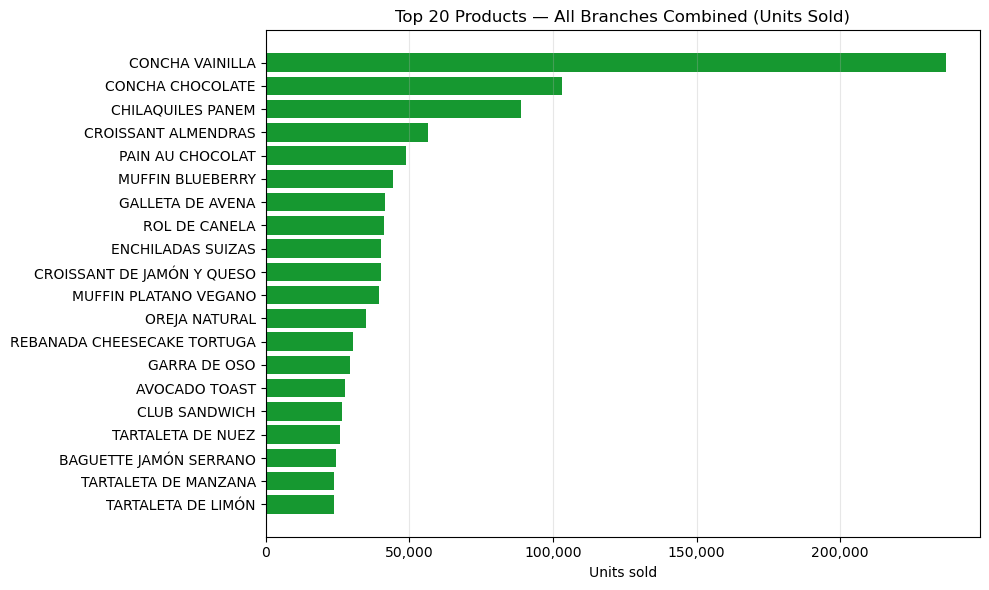

In [5]:
top_items_overall = (
    base.groupby("item", as_index=False)["quantity"]
        .sum()
        .rename(columns={"quantity": "qty_sold"})
        .sort_values("qty_sold", ascending=False)
        .reset_index(drop=True)
        .head(20)
)
top_items_overall.index = top_items_overall.index + 1

display(top_items_overall)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_items_overall["item"][::-1], top_items_overall["qty_sold"][::-1], color="#169830")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Units sold")
ax.set_title("Top 20 Products — All Branches Combined (Units Sold)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis 4 — Top 20 items per branch (by units sold)

The global top-20 mixes all branches together. Here we break it down per branch.

A product that ranks #1 globally may not even appear in the top 20 at a specific location
because each branch serves a different customer demographic (hotel guests, hospital staff,
mall shoppers, etc.).

This is the foundation for identifying the **top 5 products per branch** that the
forecasting model will predict.

In [6]:
TOP_N = 20

top_per_branch = (
    base.groupby(["sucursal", "item"], as_index=False)["quantity"]
        .sum()
        .rename(columns={"quantity": "qty_sold"})
        .sort_values(["sucursal", "qty_sold"], ascending=[True, False])
        .groupby("sucursal", as_index=False)
        .head(TOP_N)
)

for branch in sorted(top_per_branch["sucursal"].dropna().unique()):
    print(f"\n{'='*52}")
    print(f"  {branch}")
    print(f"{'='*52}")
    table = (
        top_per_branch[top_per_branch["sucursal"] == branch][["item", "qty_sold"]]
        .reset_index(drop=True)
    )
    table.index = table.index + 1
    display(table)


  Panem - Carreta


,item,qty_sold
1,CONCHA VAINILLA,23414.0
2,CONCHA CHOCOLATE,12153.0
3,GALLETA DE AVENA,6545.0
4,MUFFIN PLATANO VEGANO,5756.0
5,MUFFIN BLUEBERRY,5550.0
6,PAIN AU CHOCOLAT,5340.0
7,SUBSIDIO TEC,5151.0
8,ENSALADA CESAR,4782.0
9,CROISSANT ALMENDRAS,4686.0
10,BAGUETTE CAPRESE,4683.0



  Panem - Credi Club


,item,qty_sold
1,CONCHA VAINILLA,2680.0
2,CONCHA CHOCOLATE,1455.0
3,CHILAQUILES PANEM,1340.0
4,CONCHA UBER,679.0
5,ENCHILADAS SUIZAS,673.0
6,PAIN AU CHOCOLAT,466.0
7,MUFFIN PLATANO VEGANO,419.0
8,CROISSANT DE JAMÓN Y QUESO,418.0
9,ROL DE CANELA,394.0
10,MUFFIN BLUEBERRY,393.0



  Panem - Hospital Zambrano


...

,item,qty_sold
1,CONCHA VAINILLA,25498.0
2,CONCHA CHOCOLATE,11423.0
3,CHILAQUILES PANEM,4633.0
4,PAIN AU CHOCOLAT,3318.0
5,OREJA NATURAL,3215.0
6,CROISSANT ALMENDRAS,3189.0
7,MUFFIN BLUEBERRY,3176.0
8,GALLETA DE AVENA,2994.0
9,VASO BIO,2846.0
10,MUFFIN PLATANO VEGANO,2796.0



  Panem - Plaza QIN


,item,qty_sold
1,CONCHA VAINILLA,61794.0
2,CONCHA CHOCOLATE,22826.0
3,BAGUETTE PETITE MAYOREO 10,20326.0
4,CHILAQUILES PANEM,14705.0
5,CROISSANT ALMENDRAS,11159.0
6,GALLETA DE AVENA,9248.0
7,PAIN AU CHOCOLAT,9088.0
8,OREJA NATURAL,8911.0
9,MUFFIN BLUEBERRY,7861.0
10,CROISSANT DE JAMÓN Y QUESO,7006.0



  Panem - Punto Valle


,item,qty_sold
1,CONCHA VAINILLA,55903.0
2,CONCHA CHOCOLATE,22955.0
3,CHILAQUILES PANEM,21201.0
4,CROISSANT ALMENDRAS,16965.0
5,PAIN AU CHOCOLAT,13382.0
6,ROL DE CANELA,11900.0
7,MUFFIN BLUEBERRY,11778.0
8,ENCHILADAS SUIZAS,10698.0
9,MUFFIN PLATANO VEGANO,9491.0
10,GALLETA DE AVENA,9317.0


## Analysis 5 — Top 20 items per branch (by revenue in MXN)

Units sold and revenue don't always agree. A low-priced product sold in high volume
can rank #1 by quantity but much lower by revenue — and vice versa.

Comparing both rankings tells us whether the top-5 products we forecast should be
chosen by volume (operational planning) or revenue (business impact).

In [7]:
top_revenue_per_branch = (
    base.groupby(["sucursal", "item"], as_index=False)["total_ticket"]
        .sum()
        .rename(columns={"total_ticket": "revenue_mxn"})
        .sort_values(["sucursal", "revenue_mxn"], ascending=[True, False])
        .groupby("sucursal", as_index=False)
        .head(TOP_N)
)

for branch in sorted(top_revenue_per_branch["sucursal"].dropna().unique()):
    print(f"\n{'='*52}")
    print(f"  {branch}")
    print(f"{'='*52}")
    table = (
        top_revenue_per_branch[top_revenue_per_branch["sucursal"] == branch][["item", "revenue_mxn"]]
        .reset_index(drop=True)
    )
    table.index = table.index + 1
    display(table)


  Panem - Carreta


,item,revenue_mxn
1,SUBSIDIO TEC,2338107.0
2,CONCHA VAINILLA,1885198.6
3,ENSALADA CESAR,1272097.4
4,BAGUETTE JAMÓN SERRANO,1227156.5
5,SANDWICH ENSALADA POLLO,1209164.9
6,MINI PIZZA PEPPERONI SUB,1159877.0
7,CONCHA CHOCOLATE,1062027.0
8,BAGUETTE CAPRESE,1032676.4
9,MINI PIZZA VEGGIE SUB,1032516.0
10,MINI CHILAQUILES VERDES SUB,1012328.0



  Panem - Credi Club


,item,revenue_mxn
1,CHILAQUILES PANEM,390840.00
2,CONCHA VAINILLA,192482.10
3,ENCHILADAS SUIZAS,154325.08
4,CONCHA UBER,138356.40
5,CHILAQUILES PANEM UBER,128046.40
6,CONCHA CHOCOLATE,111877.40
7,CLUB SANDWICH,83441.10
8,ROL DE CANELA,78965.60
9,CROISSANT DE BERRIES,78531.40
10,PAIN AU CHOCOLAT,77478.30



  Panem - Hospital Zambrano


...

,item,revenue_mxn
1,CONCHA VAINILLA,2889635.89
2,CHILAQUILES PANEM,2163509.60
3,CONCHA CHOCOLATE,1563969.94
4,AVOCADO TOAST,847534.66
5,PAIN AU CHOCOLAT,810484.95
6,MUFFIN BLUEBERRY,807355.80
7,ENCHILADAS SUIZAS,788981.80
8,CROISSANT ALMENDRAS,780300.85
9,CROISSANT DE JAMÓN Y QUESO,758031.85
10,OREJA NATURAL,680823.30



  Panem - Plaza QIN


,item,revenue_mxn
1,CONCHA VAINILLA,7.290861e+06
2,CHILAQUILES PANEM,6.796538e+06
3,CONCHA CHOCOLATE,3.373827e+06
4,ENCHILADAS SUIZAS,2.630331e+06
5,CROISSANT ALMENDRAS,2.551549e+06
6,CROISSANT DE JAMÓN Y QUESO,2.454720e+06
7,PAIN AU CHOCOLAT,2.122816e+06
8,MUFFIN BLUEBERRY,1.900905e+06
9,AVOCADO TOAST,1.843996e+06
10,OREJA NATURAL,1.718617e+06



  Panem - Punto Valle


,item,revenue_mxn
1,CHILAQUILES PANEM,1.149895e+07
2,CONCHA VAINILLA,8.389175e+06
3,ENCHILADAS SUIZAS,5.147530e+06
4,CROISSANT ALMENDRAS,4.304528e+06
5,CONCHA CHOCOLATE,3.917439e+06
6,CROISSANT DE JAMÓN Y QUESO,3.735278e+06
7,AVOCADO TOAST,3.722161e+06
8,PAIN AU CHOCOLAT,3.496689e+06
9,CLUB SANDWICH,3.302354e+06
10,ROL DE CANELA,3.252893e+06


## Summary

Key takeaways from this notebook:
- **Branch size varies a lot** — check the `pct` column in Analysis 1 to see how unequal the distribution is
- **Each branch has a distinct product mix** — a single global model would miss local patterns
- **Volume ≠ Revenue** — review both Analysis 4 and 5 before finalizing the top-5 list per branch

**Next step:** `03_eda_weather_temporal.ipynb` — understand how temperature, day of week,
and time of day affect what customers buy.